<img src='http://calculus.math.sharif.ir/logo.png' alt="SUT logo" width=200 height=200 align=left class="saturate" >

<div direction=ltr align=center>
<font face=Vazirmatn size=6 color=cyan>
علی قلیچ خانی
    <br>
98107622
    <br>
پروژه درس نظریه بازی ها

# Graphical presentation of extensive form games and finding SPNEs in them

## Explanation of the Algorithm to Find SPNE

### Initialization:
The find_spne method initializes an empty dictionary spne to store the subgame perfect Nash equilibria.

### Topological Sorting:
The method processes nodes in reverse topological order using nx.topological_sort(self.tree). This ensures that terminal nodes (leaves) are processed first, followed by their predecessors.

### Terminal Nodes:
If a node is a terminal node (i.e., it has a payoff), its SPNE is simply its payoff.

### Non-terminal Nodes:
For non-terminal nodes:

The method identifies the player making the decision at that node.
It then examines all possible choices (successors) from that node.
It selects the best choice based on the player's payoff (maximizing for player 1 and 2 respectively).
The SPNE for the node is set to the SPNE of the best choice successor.
The best choice is stored, and the corresponding edge is added to spne_edges.

### Simultaneous Moves: (Commented out in the code)
Simultaneous moves would require a different handling where the best choices for both players need to be identified simultaneously.

### Explanation of the Code
The code defines an ExtensiveFormGame class to represent and analyze extensive-form games. The class includes methods to build the game tree, add nodes and edges, and find and display subgame perfect Nash equilibria (SPNE). The game tree is visualized with nodes representing players or payoffs, and edges representing actions. The find_spne method uses backward induction on a topologically sorted list of nodes to determine the SPNE, identifying the best choices for players at each decision node and marking these choices for visualization.


## Time and Space Complexity
### Time Complexity:

Building the tree involves adding nodes and edges, which takes 
𝑂
(
𝑉
+
𝐸
)
, where 
𝑉
is the number of nodes and 
𝐸
is the number of edges.
Topological sorting takes 
𝑂
(
𝑉
+
𝐸
)
.
Finding the SPNE involves processing each node and its successors, which also takes 
𝑂
(
𝑉
+
𝐸
)
.
Overall, the time complexity is 
𝑂
(
𝑉
+
𝐸
)
.

### Space Complexity:

The space complexity is primarily determined by the storage of the tree, payoffs, and the SPNE dictionary.
Storing the tree requires 
𝑂
(
𝑉
+
𝐸
)
 space.
The payoffs and SPNE dictionary require 
𝑂
(
𝑉
)
 space.
Overall, the space complexity is 
𝑂
(
𝑉
+
𝐸
)


In [1]:
import networkx as nx
import matplotlib.pyplot as plt


In [2]:
class ExtensiveFormGame:
    def __init__(self):
        self.tree = nx.DiGraph()  # Initialize a directed graph to represent the game tree
        self.payoffs = {}  # Dictionary to store the payoffs at terminal nodes
        self.simultaneous_moves = []  # List to store simultaneous moves
        self.spne_edges = []  # List to store edges that are part of SPNE

    def add_node(self, node, player=None, payoff=None):
        self.tree.add_node(node, player=player, payoff=payoff)  # Add a node to the game tree
        if payoff:
            self.payoffs[node] = payoff  # If the node has a payoff, add it to the payoffs dictionary

    def add_edge(self, from_node, to_node, action):
        self.tree.add_edge(from_node, to_node, action=action)  # Add an edge to the game tree

    def add_simultaneous_move(self, node1, node2):
        self.simultaneous_moves.append((node1, node2))  # Add a simultaneous move

    def hierarchical_pos(self, G, root=None, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5):
        # Compute the hierarchical positions for nodes in the tree for visualization
        pos = self._hierarchical_pos(G, root, width, vert_gap, vert_loc, xcenter)
        return pos

    def _hierarchical_pos(self, G, root, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5, pos=None, parent=None,
                          parsed=[]):
        if pos is None:
            pos = {root: (xcenter, vert_loc)}  # Initialize position for the root node
        else:
            pos[root] = (xcenter, vert_loc)  # Set position for the root node

        children = list(G.neighbors(root))  # Get children of the root node
        if not isinstance(G, nx.DiGraph) and parent is not None:
            children.remove(parent)  # Remove the parent to avoid cycles

        if len(children) != 0:
            dx = width / len(children)  # Width for each child
            nextx = xcenter - width / 2 - dx / 2
            for child in children:
                nextx += dx
                pos = self._hierarchical_pos(G, child, width=dx, vert_gap=vert_gap, vert_loc=vert_loc - vert_gap,
                                             xcenter=nextx, pos=pos, parent=root, parsed=parsed)
        return pos

    def display_tree(self):
        pos = self.hierarchical_pos(self.tree, root='Root')  # Get hierarchical positions
        labels = {node: (data['payoff'] if data['payoff'] is not None else data['player']) for node, data in
                  self.tree.nodes(data=True)}  # Set labels for nodes
        actions = nx.get_edge_attributes(self.tree, 'action')  # Get edge labels

        plt.figure(figsize=(12, 8))
        nx.draw(self.tree, pos, with_labels=True, labels=labels, node_size=2000, node_color='skyblue', font_size=10,
                font_color='black', font_weight='bold')
        nx.draw_networkx_edge_labels(self.tree, pos, edge_labels=actions, font_color='red')

        for (node1, node2) in self.simultaneous_moves:
            x1, y1 = pos[node1]
            x2, y2 = pos[node2]
            plt.plot([x1 + 0.03, x2 - 0.03], [y1, y2], 'k--')

        # Highlight SPNE edges in yellow
        for edge in self.spne_edges:
            nx.draw_networkx_edges(self.tree, pos, edgelist=[edge], edge_color='yellow', width=2.5)

        plt.show()

    def find_spne(self):
        spne = {}
        for node in reversed(list(nx.topological_sort(self.tree))):  # Process nodes in reverse topological order
            if node in self.payoffs:
                spne[node] = self.payoffs[node]  # Terminal nodes' SPNE are their payoffs
            else:
                player = self.tree.nodes[node]['player']
                choices = list(self.tree.successors(node))  # Get successors of the node
                if player and choices:
                    best_choice = max(choices, key=lambda n: spne[n][0] if player == 'P1' else spne[n][1])  # Find the best choice for the player
                    spne[node] = spne[best_choice]  # Set SPNE for the node
                    self.tree.nodes[node]['best_choice'] = best_choice  # Mark the best choice
                    self.spne_edges.append((node, best_choice))  # Add the edge to SPNE edges

        # Handle simultaneous moves (commented out for now)
        # for (node1, node2) in self.simultaneous_moves:
        #     player1 = self.tree.nodes[node1]['player']
        #     player2 = self.tree.nodes[node2]['player']
        #     choices1 = list(self.tree.successors(node1))
        #     choices2 = list(self.tree.successors(node2))

        #     best_choice1 = max(choices1, key=lambda n: spne[n][0])
        #     best_choice2 = max(choices2, key=lambda n: spne[n][1])

        #     spne[node1] = spne[best_choice1]
        #     spne[node2] = spne[best_choice2]

        #     self.tree.nodes[node1]['best_choice'] = best_choice1
        #     self.tree.nodes[node2]['best_choice'] = best_choice2
        #     self.spne_edges.append((node1, best_choice1))
        #     self.spne_edges.append((node2, best_choice2))

        return spne

    def display_spne(self):
        spne = self.find_spne()  # Find SPNE
        strategies = {}

        for node in nx.topological_sort(self.tree):
            if 'best_choice' in self.tree.nodes[node]:
                best_choice = self.tree.nodes[node]['best_choice']
                action = self.tree.edges[(node, best_choice)]['action']
                player = self.tree.nodes[node]['player']
                if player not in strategies:
                    strategies[player] = []
                strategies[player].append((node, action))

        spne_format = "SPNE = ("
        spne_format += ", ".join(f"({', '.join(action for _, action in actions)})" for player, actions in strategies.items())
        spne_format += ")"
        print(spne_format)


In [3]:
game = ExtensiveFormGame()

# Add nodes: (node, player, payoff)
game.add_node('Root', player='P1')
game.add_node('A', player='P2')
game.add_node('B', player='P2')
game.add_node('C', player='P2')
game.add_node('D', player='P3')
game.add_node('E', player='P3')
game.add_node('F', payoff=(9, 19, 13))
game.add_node('G', payoff=(13, 3, 16))
game.add_node('H', payoff=(17, 20, 2))
game.add_node('I', payoff=(20, 9, 5))
game.add_node('J', payoff=(2, 15, 10))
game.add_node('K', payoff=(14, 5, 11))
game.add_node('L', payoff=(19, 7, 14))
game.add_node('M', payoff=(2, 0, 7))

# Add edges: (from_node, to_node, action)
game.add_edge('Root', 'A', action='A')
game.add_edge('Root', 'B', action='B')
game.add_edge('Root', 'C', action='C')
game.add_edge('A', 'F', action='a')
game.add_edge('A', 'G', action='b')
game.add_edge('B', 'D', action='c')
game.add_edge('B', 'E', action='d')
game.add_edge('D', 'H', action='L')
game.add_edge('D', 'I', action='M')
game.add_edge('E', 'J', action='N')
game.add_edge('E', 'K', action='O')
game.add_edge('C', 'L', action='e')
game.add_edge('C', 'M', action='f')

In [4]:
game.display_spne()

SPNE = ((C), (a, c, e), (L, N))


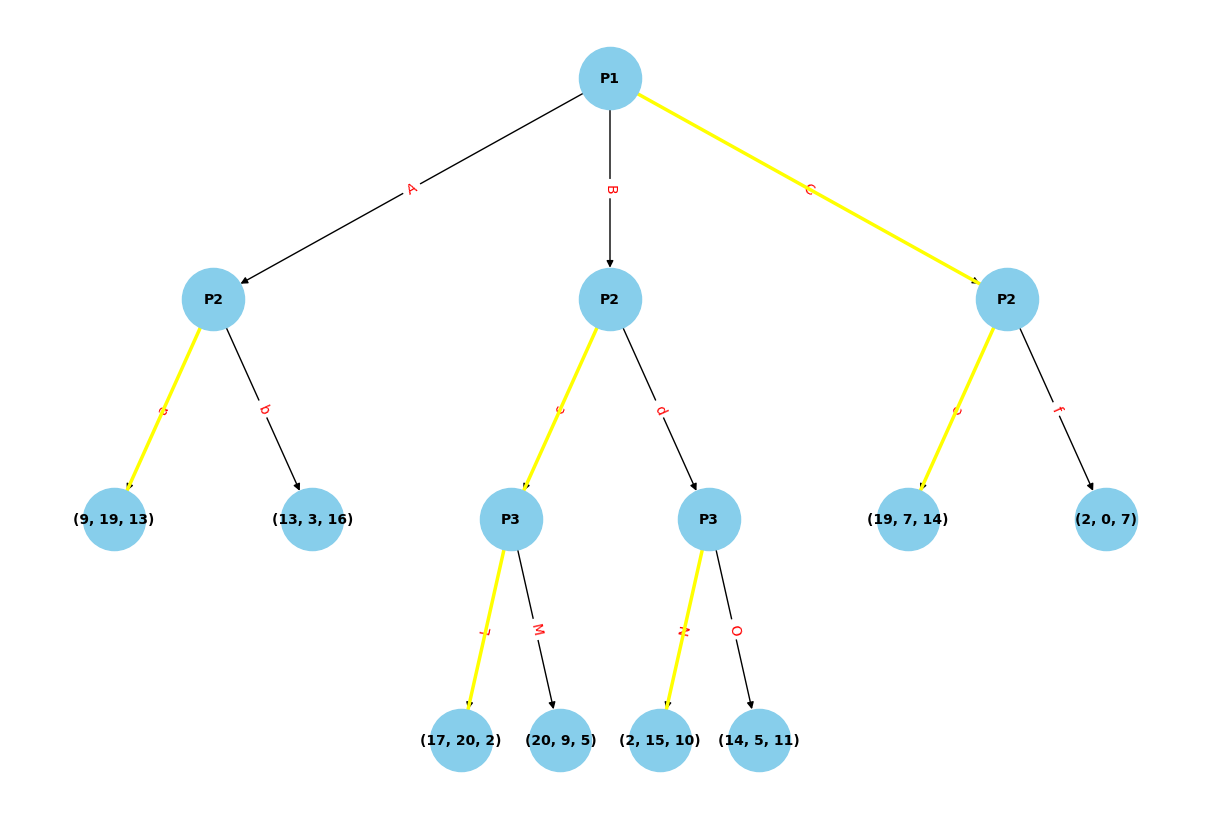

In [5]:
game.display_tree()
